In [1]:
from UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
from scipy.interpolate import UnivariateSpline, PchipInterpolator
import pandas as pd
from scipy.optimize import curve_fit

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [2]:
# ===> ANALYZE SCURVE

In [3]:
outputfile = "tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK"

In [4]:
Tramp1     = 11.2
wait_ramp1 = 121.5 + Tramp1

Tramp2     = 11.2 + wait_ramp1
wait_ramp2 = 121.5 + Tramp2

Tramp3     = 11.2 + wait_ramp2
wait_ramp3 = 121.5 + Tramp3

In [5]:
# Make Plot Nicer
def plotter_nicer(flag = True):
    if(flag):
        plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
        plt.xlabel("bias", loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
    plt.ylim(-1.1,1.1)
    #plt.xlim(-3, 3)
    
    plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
    #plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
    plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
    #plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
    plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

In [6]:
def get_annihilations(output, bias):
    f = np.load(output)
    R = f["position"]
    t = f["Time"]

    m = np.isfinite(t)
    z = R[m, 2]
    t = t[m]

    z_up   = zacceptance_max - 1e-3
    z_down = zacceptance_min + 1e-3

    def counts(tmin=None, tmax=None):
        mt = np.ones_like(t, dtype=bool)
        if tmin is not None: mt &= (t > tmin)
        if tmax is not None: mt &= (t < tmax)
        nup   = np.sum((z >= z_up)   & mt)
        ndown = np.sum((z <= z_down) & mt)
        return nup, ndown

    def asym(nup, ndown):
        n = nup + ndown
        if n == 0:
            return np.nan, np.nan
        A = (ndown - nup) / n
        dA = np.sqrt(np.abs(1 - A**2) / n)
        if(dA == 0): dA = 0.0001
        return A, dA

    # totale (t finito)
    A, dA = asym(*counts())

    # segmenti: (tmin, tmax)
    windows = {
        "A0":  (0,        Tramp1),
        "A0b": (Tramp1,   wait_ramp1),
        "A1":  (wait_ramp1, Tramp2),
        "A1b": (Tramp2,   wait_ramp2),
        "A2":  (wait_ramp2, Tramp3),
        "A2b": (Tramp3,   None),
    }

    (A0, dA0)   = asym(*counts(*windows["A0"]))
    (A0b, dA0b) = asym(*counts(*windows["A0b"]))
    (A1, dA1)   = asym(*counts(*windows["A1"]))
    (A1b, dA1b) = asym(*counts(*windows["A1b"]))
    (A2, dA2)   = asym(*counts(*windows["A2"]))
    (A2b, dA2b) = asym(*counts(*windows["A2b"]))

    return [A0, A1, A2, A, A0b, A1b, A2b], [dA0, dA1, dA2, dA, dA0b, dA1b, dA2b]

# Load the Data

In [7]:
def linear(x,m,q):
    return m*x + q

def shift(m,q):
    return -q/m

# Load the 2025 Scurve data
cols = [
    "run", "bias", "type_ramp",
    "segment1", "err_segment1",
    "segment2", "err_segment2",
    "segment3", "err_segment3",
    "segment4", "err_segment4"
]

# Asymmetry during gravity ramps
df_onlyramps = pd.read_csv(
    "../comparison_simulation_data/data_onlyramp.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)

# Asymmetries during the wait time between segments
df_onlywait = pd.read_csv(
    "../comparison_simulation_data/data_onlywait.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)

# Shift everything to zero
mask = df_onlyramps['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment2'][mask])
b1 = (df_onlyramps['bias'][mask] - shift(popt[0], popt[1])).to_list()

mask = df_onlyramps['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment3'][mask])
b2 = (df_onlyramps['bias'][mask] - shift(popt[0], popt[1])).to_list()

mask = df_onlywait['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment2'][mask])
b3 = (df_onlywait['bias'][mask] - shift(popt[0], popt[1])).to_list()

mask = df_onlywait['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment3'][mask])
b4 = (df_onlywait['bias'][mask] - shift(popt[0], popt[1])).to_list()

# SIMULATION, Load the Data

In [28]:
files = os.listdir("output/")

# get all the simulation files relative to a configuration
outputs = [f"output/" + item for item in files if f"{outputfile}" in item]
print("Outputs files: \n", outputs)

simulation_dataset = {}

# create containers for Asymmetries
A0,   A1,   A2, At   = [],[],[],[]
A0b,  A1b,  A2b      = [],[],[]
dA0,  dA1,  dA2, dAt = [],[],[],[]
dA0b, dA1b, dA2b     = [],[],[]
b_simulation               = []

# get the asymetries for each individual segment
for output in outputs:
    #print("-"*20)
    bias = output.split("_")[8].replace(".npz","") # get the bias
    A, dA = get_annihilations(output, bias)
    #- - - - - - - - - - - - - - - - - - - - - - - - - -
    A0.append(A[0]);  dA0.append(dA[0])   # 1st ramp
    A0b.append(A[4]); dA0b.append(dA[4])  # 1st boil-off
    #- - - - - - - - - - - - - - - - - - - - - - - - - -
    A1.append(A[1]);  dA1.append(dA[1])   # 2nd ramp
    A1b.append(A[5]); dA1b.append(dA[5])  # 2nd boil-off
    #- - - - - - - - - - - - - - - - - - - - - - - - - -
    A2.append(A[2]);  dA2.append(dA[2])   # 3rd ramp
    A2b.append(A[6]); dA2b.append(dA[6])  # 3rd boil-off
    #- - - - - - - - - - - - - - - - - - - - - - - - - -
    At.append(A[3]);  dAt.append(dA[3])   # total

    b_simulation.append( float( bias.replace("p",".").replace("g","") ))

    #
    #print(bias, f"{A[0]:.2}",  f"{dA[0]:.2f}")
    #print(bias, f"{A[1]:.2f}", f"{dA[1]:.2f}")
    #print(bias, f"{A[2]:.2f}", f"{dA[2]:.2f}")

    
b_simulation = np.array(b_simulation)
#print(b_simulation)

At = np.array(At)
dAt = np.array(dAt)
A0 = np.array(A0)
A1 = np.array(A1)
A2 = np.array(A2)
A0b = np.array(A0)
A1b = np.array(A1b)
A2b = np.array(A2b)
A0 = np.array(A0)
dA1 = np.array(dA1)
dA2 = np.array(dA2)
dA0b = np.array(dA0)
dA1b = np.array(dA1b)
dA2b = np.array(dA2b)

print(A1b)

# Spline of simulation
idx = np.argsort(b_simulation) # sort the biases
b_simulation = b_simulation[idx]
if not np.isnan(A1[idx]).any():
    w = 1.0 / dA1
    S_2nd = PchipInterpolator(b_simulation, A1[idx])
if not np.isnan(A2[idx]).any():
    w = 1.0 / dA2
    S_3rd = PchipInterpolator(b_simulation, A2[idx])
if not np.isnan(A1b[idx]).any():
    w = 1.0 / dA1b
    S_2nd_boiloff = PchipInterpolator(b_simulation, A1b[idx])
if not np.isnan(A2b[idx]).any():
    w = 1.0 / dA2b
    S_3rd_boiloff = PchipInterpolator(b_simulation, A2b[idx])

Outputs files: 
 ['output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_-0p75g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_1p0g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_-0p5g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_0p25g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_0p75g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_0p0g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_-0p37g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_0p5g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_-1p25g.npz', 'output/tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK_-0p25g.npz']
[-1.   1.  -1.   1.   1.  -0.1 -1.   1.  -1.  -1. ]


# Compute the Metric, Chiquare between data and simulation

In [29]:
# Model factory
def make_model(spl):
    # wrap spline
    def model(x, c):
        return spl(x - c)
    # return the wrapped model
    return model

def chisq(simulation, x, y, dy, y_predict):
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)
    dy = np.asarray(dy, float)
    y_predict = np.asarray(y_predict, float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(dy) & (dy > 0)

    return np.sum(((y[mask] - y_predict[mask]) / dy[mask])**2)

def compute_segment_chisq(bias, df, segment, simulation, c):
    mask = df["type_ramp"] == "short"

    x  = bias
    y  = df[f"segment{segment}"][mask]
    dy = df[f"err_segment{segment}"][mask]
    y_predict = simulation(x, c)

    return chisq(simulation, x, y, dy, y_predict)

In [30]:
# Make models from spline
if not np.isnan(A1).any(): model_S2nd = make_model(S_2nd)
if not np.isnan(A2).any(): model_S3rd = make_model(S_3rd)
if not np.isnan(A1b).any(): model_S2nd_bf = make_model(S_2nd_boiloff)
if not np.isnan(A1b).any(): model_S3rd_bf = make_model(S_3rd_boiloff)

mask = df_onlyramps['type_ramp' ] == 'short'

c1 = 0
if not np.isnan(A1).any():
    popt, pcovm = curve_fit(model_S2nd, 
                            b1, 
                            df_onlyramps['segment2'][mask],
                            sigma = df_onlyramps['err_segment2'][mask],
                            p0 = [0],
                            bounds = ((0.0),(0.3)),
                            absolute_sigma =  True)
    c1 = popt[0]
print(popt, " +/- ", np.sqrt(pcovm))

c2 = 0
if not np.isnan(A2).any():
    popt, pcovm = curve_fit(model_S3rd, 
                            b2, 
                            df_onlyramps['segment3'][mask],
                            sigma = df_onlyramps['err_segment3'][mask],
                            p0 = [0],
                            bounds = ((0.0),(0.3)),
                            absolute_sigma =  True)
    c2 = popt[0]
    print(popt, " +/- ", np.sqrt(pcovm))

mask = df_onlywait['type_ramp' ] == 'short'

c3 = 0
if not np.isnan(A1b).any():
    popt, pcovm = curve_fit(model_S2nd_bf, 
                            b1, 
                            df_onlywait['segment2'][mask],
                            sigma = df_onlywait['err_segment2'][mask],
                            p0 = [0],
                            bounds = ((0.0),(0.3)),
                            absolute_sigma =  True)
    c3 = popt[0]
    print(popt, " +/- ", np.sqrt(pcovm))

c4 = 0
if not np.isnan(A2b).any():
    popt, pcovm = curve_fit(model_S3rd_bf, 
                            b1, 
                            df_onlywait['segment3'][mask],
                            sigma = df_onlywait['err_segment3'][mask],
                            p0 = [0],
                            bounds = ((0.0),(0.3)),
                            absolute_sigma =  True)
    c4 = popt[0]
    print(popt, " +/- ", np.sqrt(pcovm))


[0.18722135]  +/-  [[0.0127116]]
[0.13030464]  +/-  [[0.00586592]]
[0.15531479]  +/-  [[0.00778996]]
[0.16713759]  +/-  [[0.00546582]]


# PLOT THE RESULTS

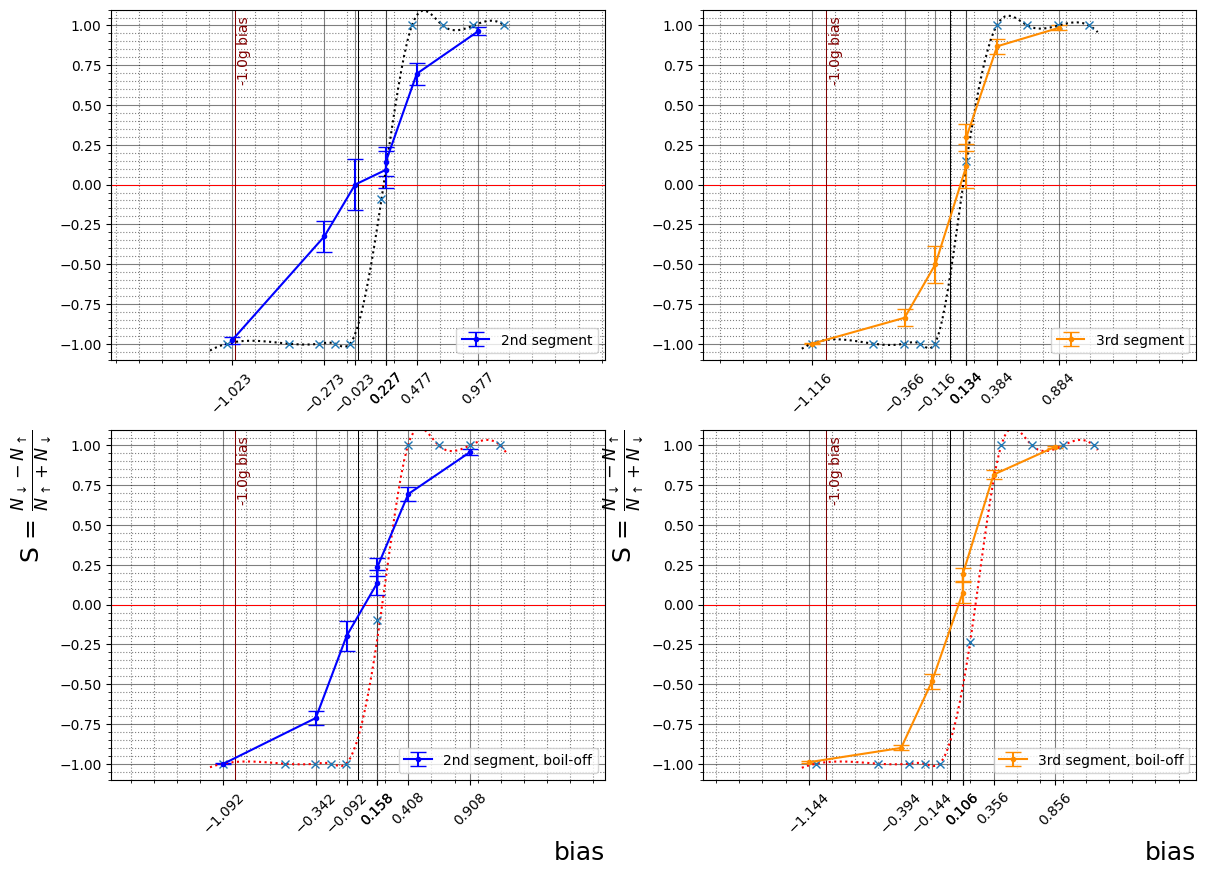

In [31]:
def Plotter_data(x, y, dy, color, label):
    plt.errorbar(x, y, dy,
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = color, 
             label = label)
    plt.xticks(x, rotation = 45, fontsize = 10)
    plt.xlim(-2,+2)
    plt.legend()



plt.figure(1, figsize = (14,10))

plt.subplot(2,2,1)
plotter_nicer(False) ;xgrid = np.linspace(-1.2, 1.2, 100)
if not np.isnan(A1).any(): 
    plt.errorbar(xgrid, model_S2nd(xgrid, c1),  linestyle = "dotted", markersize = 6,color = "black", capsize = 4)
    plt.errorbar(b_simulation + c1, A1[idx], marker = "x", linestyle = "")
# DATASET 2025
mask = df_onlyramps['type_ramp' ] == 'short'
Plotter_data(b1, df_onlyramps['segment2'][mask], df_onlyramps['err_segment2'][mask], "blue", "2nd segment")

plt.subplot(2,2,2)
plotter_nicer(False); 
if not np.isnan(A2).any(): 
    plt.errorbar(xgrid, model_S3rd(xgrid, c2),  linestyle = "dotted", markersize = 6, color = "black", capsize = 4)
    plt.errorbar(b_simulation + c2, A2[idx], marker = "x", linestyle = "")
    
Plotter_data(b2, df_onlyramps['segment3'][mask], df_onlyramps['err_segment3'][mask], "darkorange", "3rd segment")


plt.subplot(2,2,3)
if not np.isnan(A1b).any(): 
    plt.errorbar(xgrid, model_S2nd_bf(xgrid, c3), linestyle = "dotted", markersize = 6,color = "red", capsize = 4)
    plt.errorbar(b_simulation + c3, A1b[idx], marker = "x", linestyle = "")
mask = df_onlywait['type_ramp' ] == 'short'
Plotter_data(b3, df_onlywait['segment2'][mask], df_onlywait['err_segment2'][mask], "blue", "2nd segment, boil-off")
plotter_nicer()

plt.subplot(2,2,4)
if not np.isnan(A2b).any():
    plt.errorbar(xgrid, model_S3rd_bf(xgrid, c4), linestyle = "dotted", markersize = 6,  color = "red",capsize = 4)
    plt.errorbar(b_simulation + c4, A2b[idx], marker = "x", linestyle = "")
Plotter_data(b4, df_onlywait['segment3'][mask], df_onlywait['err_segment3'][mask], "darkorange", "3rd segment, boil-off")
plotter_nicer()

plt.savefig(f"output/figures/output_scurve/{outputfile}_Scurve.png", bbox_inches = 'tight')

# Save Metric

In [32]:
data = np.load("output/" + outputfile + "_0p0g.npz")
d = dict(data)

chisq_list = []

if not np.isnan(A1).any():
    chisq_list.append(compute_segment_chisq(b1, df_onlyramps, 2, model_S2nd, c1))
else:
    chisq_list.append(99999)
if not np.isnan(A2).any():
    chisq_list.append(compute_segment_chisq(b2, df_onlyramps, 3, model_S3rd, c2))
else:
    chisq_list.append(99999)
if not np.isnan(A1b).any():
    chisq_list.append(compute_segment_chisq(b3, df_onlywait,  2, model_S2nd_bf, c3))
else:
    chisq_list.append(99999)
if not np.isnan(A2b).any():
    chisq_list.append(compute_segment_chisq(b4, df_onlywait,  3, model_S3rd_bf, c4))
else:
    chisq_list.append(99999)

d["Chisq_S"] = np.array(chisq_list)

np.savez("output/" + outputfile + "_0p0g.npz", **d)
print(chisq_list)
print("GOODCOFFEE")

[111.98313237649765, 40.99638414766514, 254.0749019458761, 565.6494843566663]
GOODCOFFEE
